In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("../data/hotel_bookings_feature_engineered.csv")

print("Shape:", df.shape)
df.head()

Shape: (119378, 46)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,lead_time_group,has_special_request,has_booking_changes,was_on_waiting_list,requires_parking,has_children_or_babies,adr_per_guest,has_weekend_stay,arrival_month_num,arrival_season
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,181-365,0,1,0,0,0,0.0,0,7,Summer
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,365+,0,1,0,0,0,0.0,0,7,Summer
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0-7,0,0,0,0,0,75.0,0,7,Summer
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,8-30,0,0,0,0,0,75.0,0,7,Summer
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,8-30,1,0,0,0,0,49.0,0,7,Summer


In [3]:
print("Columns:")
print(df.columns.tolist())

Columns:
['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'booking_changes', 'deposit_type', 'agent', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'company_missing', 'total_guests', 'zero_guest_booking', 'total_stay_nights', 'zero_stay_booking', 'total_previous_bookings', 'previous_cancellation_rate', 'has_previous_booking', 'lead_time_group', 'has_special_request', 'has_booking_changes', 'was_on_waiting_list', 'requires_parking', 'has_children_or_babies', 'adr_per_guest', 'has_weekend_stay', 'arrival_month_num', 'arrival_season']


In [4]:
X = df.drop("is_canceled", axis=1)
y = df["is_canceled"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())
print("\nTarget percentage:")
print(y.value_counts(normalize=True) * 100)

X shape: (119378, 45)
y shape: (119378,)

Target distribution:
is_canceled
0    75166
1    44212
Name: count, dtype: int64

Target percentage:
is_canceled
0    62.9647
1    37.0353
Name: proportion, dtype: float64


In [5]:
from sklearn.model_selection import train_test_split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training set shape: (95502, 45)
Testing set shape: (23876, 45)

Training target distribution:
is_canceled
0    62.965174
1    37.034826
Name: proportion, dtype: float64

Testing target distribution:
is_canceled
0    62.962808
1    37.037192
Name: proportion, dtype: float64


In [7]:
# Numerical columns
numerical_cols = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Categorical columns
categorical_cols = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Number of numerical columns:", len(numerical_cols))
print("Numerical columns:")
print(numerical_cols)

print("\nNumber of categorical columns:", len(categorical_cols))
print("Categorical columns:")
print(categorical_cols)

Number of numerical columns: 33
Numerical columns:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'company_missing', 'total_guests', 'zero_guest_booking', 'total_stay_nights', 'zero_stay_booking', 'total_previous_bookings', 'previous_cancellation_rate', 'has_previous_booking', 'has_special_request', 'has_booking_changes', 'was_on_waiting_list', 'requires_parking', 'has_children_or_babies', 'adr_per_guest', 'has_weekend_stay', 'arrival_month_num']

Number of categorical columns: 12
Categorical columns:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'deposit_type', 'agent', 'customer_type', 'lead_time_group'

In [8]:
print("Numerical columns:")
for col in numerical_cols:
    print("-", col)

print("\nCategorical columns:")
for col in categorical_cols:
    print("-", col)

Numerical columns:
- lead_time
- arrival_date_year
- arrival_date_week_number
- arrival_date_day_of_month
- stays_in_weekend_nights
- stays_in_week_nights
- adults
- children
- babies
- is_repeated_guest
- previous_cancellations
- previous_bookings_not_canceled
- booking_changes
- days_in_waiting_list
- adr
- required_car_parking_spaces
- total_of_special_requests
- company_missing
- total_guests
- zero_guest_booking
- total_stay_nights
- zero_stay_booking
- total_previous_bookings
- previous_cancellation_rate
- has_previous_booking
- has_special_request
- has_booking_changes
- was_on_waiting_list
- requires_parking
- has_children_or_babies
- adr_per_guest
- has_weekend_stay
- arrival_month_num

Categorical columns:
- hotel
- arrival_date_month
- meal
- country
- market_segment
- distribution_channel
- reserved_room_type
- deposit_type
- agent
- customer_type
- lead_time_group
- arrival_season


In [9]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_cols
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            ),
            categorical_cols
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [10]:
# Fit the preprocessor only on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data using the same fitted preprocessor
X_test_processed = preprocessor.transform(X_test)

print("X_train processed shape:", X_train_processed.shape)
print("X_test processed shape:", X_test_processed.shape)

X_train processed shape: (95502, 590)
X_test processed shape: (23876, 590)


In [11]:
print("X_train processed:", X_train_processed.shape)
print("y_train:", y_train.shape)

print("X_test processed:", X_test_processed.shape)
print("y_test:", y_test.shape)

X_train processed: (95502, 590)
y_train: (95502,)
X_test processed: (23876, 590)
y_test: (23876,)


In [12]:
print("X_train has NaN:", np.isnan(X_train_processed.data).any())
print("X_test has NaN:", np.isnan(X_test_processed.data).any())

X_train has NaN: False
X_test has NaN: False


In [13]:
feature_names = preprocessor.get_feature_names_out()

print("Total processed features:", len(feature_names))

print("\nFirst 30 features:")
print(feature_names[:30])

Total processed features: 590

First 30 features:
['num__lead_time' 'num__arrival_date_year' 'num__arrival_date_week_number'
 'num__arrival_date_day_of_month' 'num__stays_in_weekend_nights'
 'num__stays_in_week_nights' 'num__adults' 'num__children' 'num__babies'
 'num__is_repeated_guest' 'num__previous_cancellations'
 'num__previous_bookings_not_canceled' 'num__booking_changes'
 'num__days_in_waiting_list' 'num__adr' 'num__required_car_parking_spaces'
 'num__total_of_special_requests' 'num__company_missing'
 'num__total_guests' 'num__zero_guest_booking' 'num__total_stay_nights'
 'num__zero_stay_booking' 'num__total_previous_bookings'
 'num__previous_cancellation_rate' 'num__has_previous_booking'
 'num__has_special_request' 'num__has_booking_changes'
 'num__was_on_waiting_list' 'num__requires_parking'
 'num__has_children_or_babies']


In [14]:
print("========== PREPROCESSING SUMMARY ==========")
print("Original features:", X.shape[1])
print("Processed features:", X_train_processed.shape[1])
print("Training samples:", X_train_processed.shape[0])
print("Testing samples:", X_test_processed.shape[0])
print("Training target:", y_train.shape[0])
print("Testing target:", y_test.shape[0])
print("============================================")

========== PREPROCESSING SUMMARY ==========
Original features: 45
Processed features: 590
Training samples: 95502
Testing samples: 23876
Training target: 95502
Testing target: 23876


In [15]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_processed,
    y_train
)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [16]:
# Predict class labels
y_pred = logistic_model.predict(X_test_processed)

# Predict probabilities for ROC-AUC later
y_pred_proba = logistic_model.predict_proba(X_test_processed)[:, 1]

print("Predictions generated successfully.")

print("\nFirst 10 predicted classes:")
print(y_pred[:10])

print("\nFirst 10 predicted probabilities:")
print(y_pred_proba[:10])

Predictions generated successfully.

First 10 predicted classes:
[1 0 0 0 1 1 0 1 0 0]

First 10 predicted probabilities:
[0.99789157 0.43744073 0.02510159 0.40028368 0.9968932  0.9956347
 0.1500899  0.99997954 0.15801741 0.04897699]


In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Logistic Regression Results")
print("----------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

Logistic Regression Results
----------------------------
Accuracy : 0.841011894789747
Precision: 0.82282205449661
Recall   : 0.7273549700327943
F1-Score : 0.7721488595438175


In [18]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[13648  1385]
 [ 2411  6432]]


In [19]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.91      0.88     15033
           1       0.82      0.73      0.77      8843

    accuracy                           0.84     23876
   macro avg       0.84      0.82      0.83     23876
weighted avg       0.84      0.84      0.84     23876



In [20]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_pred_proba)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.920899532732162


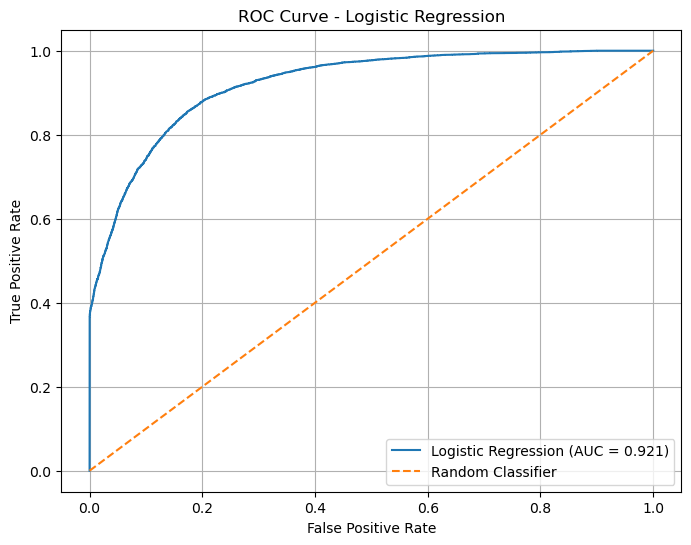

In [21]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.grid()
plt.show()

In [22]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds_to_test = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

threshold_results = []

for threshold in thresholds_to_test:
    y_pred_threshold = (y_pred_proba >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

threshold_df = pd.DataFrame(threshold_results)

print(threshold_df)

   Threshold  Precision    Recall  F1-Score
0       0.30   0.721423  0.878548  0.792270
1       0.35   0.752578  0.841683  0.794640
2       0.40   0.779562  0.801425  0.790342
3       0.45   0.802422  0.764220  0.782855
4       0.50   0.822822  0.727355  0.772149
5       0.55   0.844620  0.689698  0.759338
6       0.60   0.864399  0.652380  0.743572


In [23]:
# model 2 

from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

random_forest_model.fit(
    X_train_processed,
    y_train
)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [24]:
rf_y_pred = random_forest_model.predict(X_test_processed)

rf_y_pred_proba = random_forest_model.predict_proba(
    X_test_processed
)[:, 1]

print("Predictions generated successfully.")

print("\nFirst 10 predicted classes:")
print(rf_y_pred[:10])

print("\nFirst 10 predicted probabilities:")
print(rf_y_pred_proba[:10])

Predictions generated successfully.

First 10 predicted classes:
[1 0 0 0 1 1 0 1 0 0]

First 10 predicted probabilities:
[1.         0.36       0.055      0.165      0.985      1.
 0.055      1.         0.075      0.16346949]


In [25]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

rf_accuracy = accuracy_score(y_test, rf_y_pred)
rf_precision = precision_score(y_test, rf_y_pred)
rf_recall = recall_score(y_test, rf_y_pred)
rf_f1 = f1_score(y_test, rf_y_pred)
rf_roc_auc = roc_auc_score(y_test, rf_y_pred_proba)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1-Score :", rf_f1)
print("ROC-AUC  :", rf_roc_auc)

Random Forest Results
---------------------
Accuracy : 0.8904757915898811
Precision: 0.8879890356341889
Recall   : 0.8059482076218478
F1-Score : 0.8449819194973027
ROC-AUC  : 0.9584339572620585


In [26]:
from sklearn.metrics import classification_report

print("Random Forest Classification Report")
print("------------------------------------")
print(classification_report(y_test, rf_y_pred))

Random Forest Classification Report
------------------------------------
              precision    recall  f1-score   support

           0       0.89      0.94      0.92     15033
           1       0.89      0.81      0.84      8843

    accuracy                           0.89     23876
   macro avg       0.89      0.87      0.88     23876
weighted avg       0.89      0.89      0.89     23876



In [27]:
from sklearn.metrics import confusion_matrix

rf_cm = confusion_matrix(y_test, rf_y_pred)

print("Random Forest Confusion Matrix")
print("--------------------------------")
print(rf_cm)

Random Forest Confusion Matrix
--------------------------------
[[14134   899]
 [ 1716  7127]]


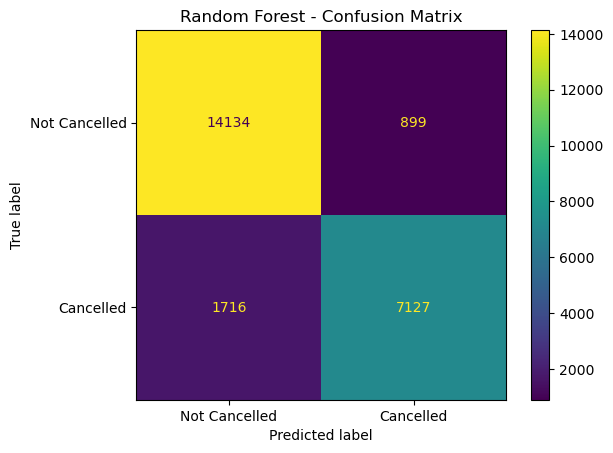

In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=["Not Cancelled", "Cancelled"]
).plot()

plt.title("Random Forest - Confusion Matrix")
plt.show()

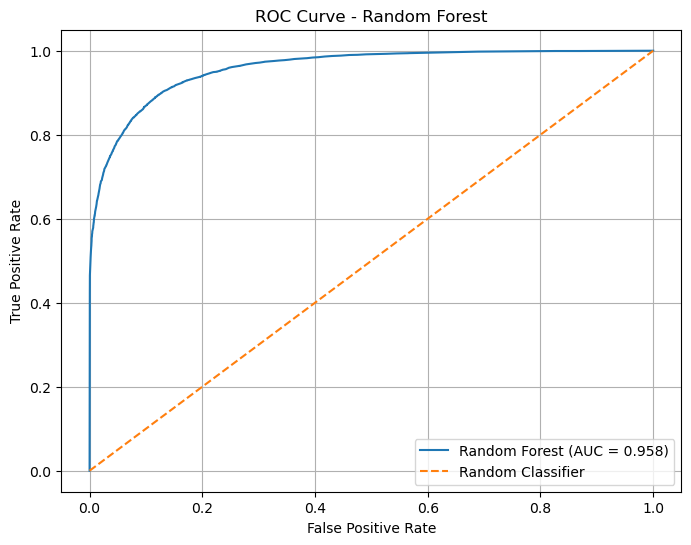

In [29]:
from sklearn.metrics import roc_curve

rf_fpr, rf_tpr, rf_thresholds = roc_curve(
    y_test,
    rf_y_pred_proba
)

plt.figure(figsize=(8, 6))

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.grid()
plt.show()

In [30]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 20 Important Features:")
print(feature_importance.head(20))

Top 20 Important Features:
                              Feature  Importance
0                      num__lead_time    0.069161
180                  cat__country_PRT    0.059978
246      cat__deposit_type_Non Refund    0.049128
14                           num__adr    0.043486
30                 num__adr_per_guest    0.041684
3      num__arrival_date_day_of_month    0.035454
16     num__total_of_special_requests    0.033096
245      cat__deposit_type_No Deposit    0.031545
2       num__arrival_date_week_number    0.030642
20             num__total_stay_nights    0.025315
25           num__has_special_request    0.024973
580          cat__lead_time_group_0-7    0.023388
5           num__stays_in_week_nights    0.022999
1              num__arrival_date_year    0.017551
565                    cat__agent_9.0    0.017071
578      cat__customer_type_Transient    0.016270
228     cat__market_segment_Online TA    0.016241
28              num__requires_parking    0.014985
15   num__required_car_

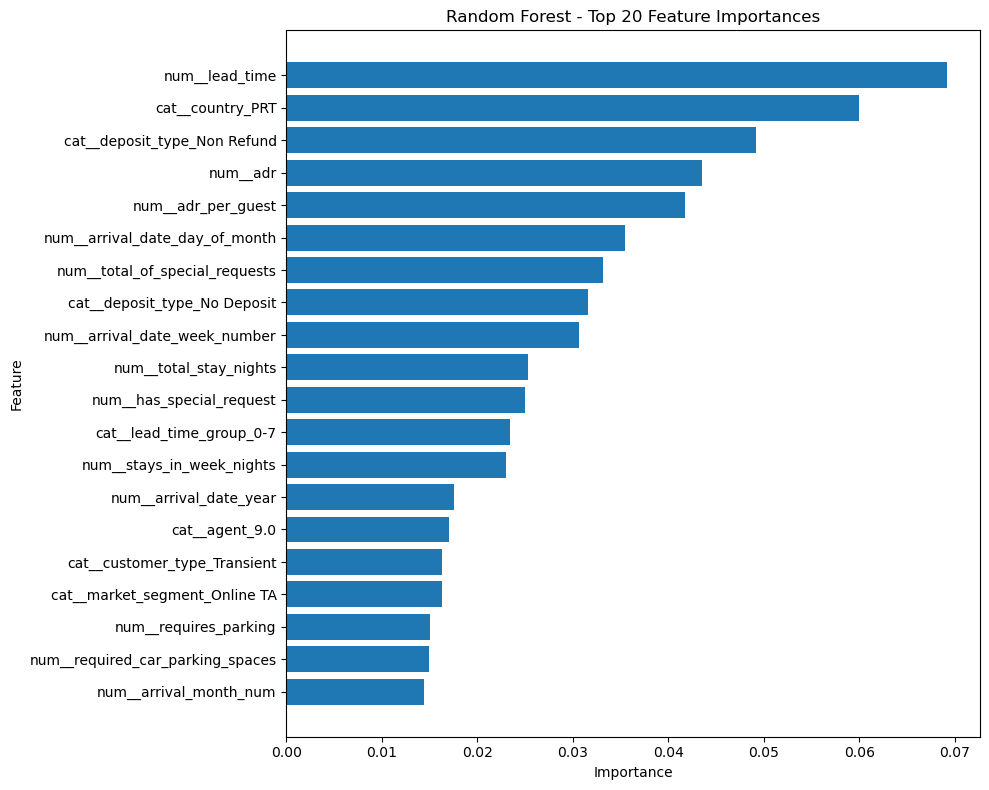

In [31]:
top_features = feature_importance.head(20).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest - Top 20 Feature Importances")
plt.tight_layout()
plt.show()

In [32]:
rf_results = {
    "Model": "Random Forest",
    "Accuracy": rf_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1-Score": rf_f1,
    "ROC-AUC": rf_roc_auc
}

print(rf_results)

{'Model': 'Random Forest', 'Accuracy': 0.8904757915898811, 'Precision': 0.8879890356341889, 'Recall': 0.8059482076218478, 'F1-Score': 0.8449819194973027, 'ROC-AUC': np.float64(0.9584339572620585)}


In [33]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.2.0


In [34]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_processed,
    y_train
)

print("XGBoost trained successfully.")

XGBoost trained successfully.


In [35]:
xgb_y_pred = xgb_model.predict(X_test_processed)

xgb_y_pred_proba = xgb_model.predict_proba(
    X_test_processed
)[:, 1]

print("Predictions generated successfully.")

print("\nFirst 10 predicted classes:")
print(xgb_y_pred[:10])

print("\nFirst 10 predicted probabilities:")
print(xgb_y_pred_proba[:10])

Predictions generated successfully.

First 10 predicted classes:
[1 0 0 0 1 1 0 1 0 0]

First 10 predicted probabilities:
[0.9985353  0.46572754 0.01040341 0.49335977 0.999062   0.9978593
 0.01538971 0.99987674 0.19168782 0.1408313 ]


In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

xgb_accuracy = accuracy_score(y_test, xgb_y_pred)
xgb_precision = precision_score(y_test, xgb_y_pred)
xgb_recall = recall_score(y_test, xgb_y_pred)
xgb_f1 = f1_score(y_test, xgb_y_pred)
xgb_roc_auc = roc_auc_score(y_test, xgb_y_pred_proba)

print("XGBoost Results")
print("----------------")
print("Accuracy :", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall   :", xgb_recall)
print("F1-Score :", xgb_f1)
print("ROC-AUC  :", xgb_roc_auc)

XGBoost Results
----------------
Accuracy : 0.874643993968839
Precision: 0.8596016719940989
Recall   : 0.7906818952844058
F1-Score : 0.8237026565353125
ROC-AUC  : 0.94834968557507


In [37]:
from sklearn.metrics import classification_report

print("XGBoost Classification Report")
print("-----------------------------")
print(classification_report(y_test, xgb_y_pred))

XGBoost Classification Report
-----------------------------
              precision    recall  f1-score   support

           0       0.88      0.92      0.90     15033
           1       0.86      0.79      0.82      8843

    accuracy                           0.87     23876
   macro avg       0.87      0.86      0.86     23876
weighted avg       0.87      0.87      0.87     23876



In [38]:
from sklearn.metrics import confusion_matrix

xgb_cm = confusion_matrix(y_test, xgb_y_pred)

print("XGBoost Confusion Matrix")
print("------------------------")
print(xgb_cm)

XGBoost Confusion Matrix
------------------------
[[13891  1142]
 [ 1851  6992]]


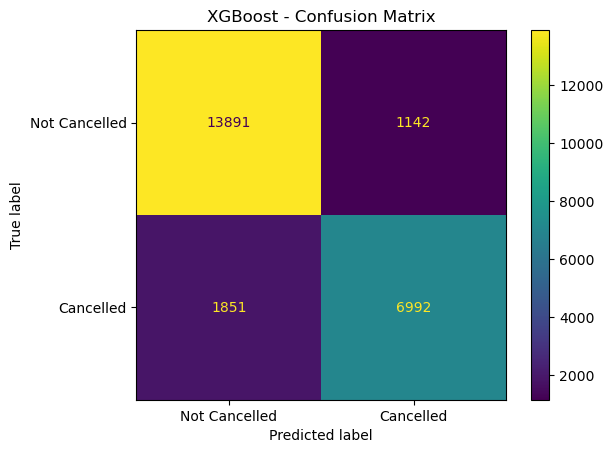

In [39]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=xgb_cm,
    display_labels=["Not Cancelled", "Cancelled"]
).plot()

plt.title("XGBoost - Confusion Matrix")
plt.show()

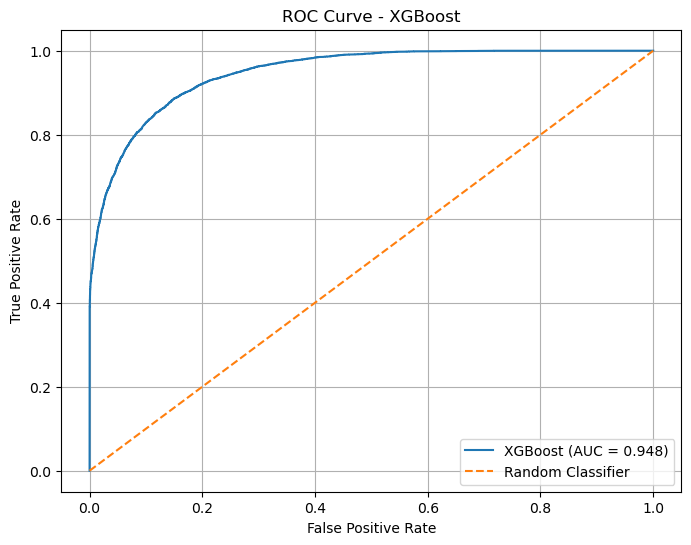

In [40]:
from sklearn.metrics import roc_curve

xgb_fpr, xgb_tpr, xgb_thresholds = roc_curve(
    y_test,
    xgb_y_pred_proba
)

plt.figure(figsize=(8, 6))

plt.plot(
    xgb_fpr,
    xgb_tpr,
    label=f"XGBoost (AUC = {xgb_roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.grid()
plt.show()

In [41]:
xgb_feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_model.feature_importances_
})

xgb_feature_importance = xgb_feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 20 XGBoost Features:")
print(xgb_feature_importance.head(20))

Top 20 XGBoost Features:
                              Feature  Importance
245      cat__deposit_type_No Deposit    0.276017
246      cat__deposit_type_Non Refund    0.194259
228     cat__market_segment_Online TA    0.051376
565                    cat__agent_9.0    0.026099
348                  cat__agent_240.0    0.025888
28              num__requires_parking    0.025291
15   num__required_car_parking_spaces    0.024490
23    num__previous_cancellation_rate    0.019015
180                  cat__country_PRT    0.016025
25           num__has_special_request    0.012555
10        num__previous_cancellations    0.012268
16     num__total_of_special_requests    0.010156
302                   cat__agent_17.0    0.009882
578      cat__customer_type_Transient    0.009024
547                    cat__agent_7.0    0.008253
247      cat__deposit_type_Refundable    0.006413
225        cat__market_segment_Direct    0.006061
580          cat__lead_time_group_0-7    0.005440
233   cat__distribution_c

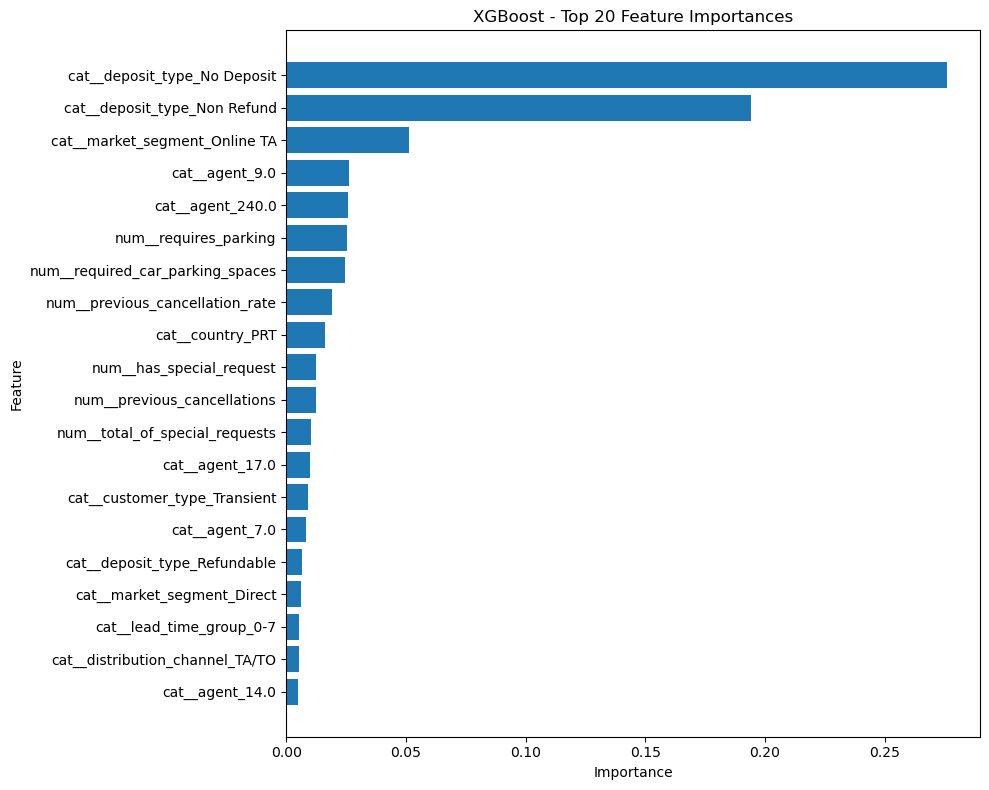

In [42]:
top_xgb_features = xgb_feature_importance.head(20).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_xgb_features["Feature"],
    top_xgb_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost - Top 20 Feature Importances")
plt.tight_layout()
plt.show()

In [43]:
xgb_results = {
    "Model": "XGBoost",
    "Accuracy": xgb_accuracy,
    "Precision": xgb_precision,
    "Recall": xgb_recall,
    "F1-Score": xgb_f1,
    "ROC-AUC": xgb_roc_auc
}

print(xgb_results)

{'Model': 'XGBoost', 'Accuracy': 0.874643993968839, 'Precision': 0.8596016719940989, 'Recall': 0.7906818952844058, 'F1-Score': 0.8237026565353125, 'ROC-AUC': np.float64(0.94834968557507)}


In [44]:
# Store Logistic Regression results
logistic_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1,
    "ROC-AUC": roc_auc
}

# Store Random Forest results
rf_results = {
    "Model": "Random Forest",
    "Accuracy": rf_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1-Score": rf_f1,
    "ROC-AUC": rf_roc_auc
}

# Store XGBoost results
xgb_results = {
    "Model": "XGBoost",
    "Accuracy": xgb_accuracy,
    "Precision": xgb_precision,
    "Recall": xgb_recall,
    "F1-Score": xgb_f1,
    "ROC-AUC": xgb_roc_auc
}

# Create comparison table
model_comparison = pd.DataFrame([
    logistic_results,
    rf_results,
    xgb_results
])

model_comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.841012,0.864399,0.652380,0.743572,0.920900
1,Random Forest,0.890476,0.887989,0.805948,0.844982,0.958434
2,XGBoost,0.874644,0.859602,0.790682,0.823703,0.948350


In [45]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

import pandas as pd
import numpy as np
import time


# ------------------------------------------------------------
# 1. Base Random Forest Model
# ------------------------------------------------------------

rf_base = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_jobs=1
)


# ------------------------------------------------------------
# 2. Hyperparameter Search Space
# ------------------------------------------------------------

param_distributions = {
    "n_estimators": [150, 200, 250, 300],
    "max_depth": [None, 10, 15, 20, 25, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False]
}


# ------------------------------------------------------------
# 3. Stratified K-Fold Cross-Validation
# ------------------------------------------------------------

cv_strategy = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)


# ------------------------------------------------------------
# 4. Randomized Hyperparameter Search
# ------------------------------------------------------------

rf_random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_distributions,
    n_iter=10,
    scoring="f1",
    cv=cv_strategy,
    random_state=42,
    n_jobs=1,
    verbose=2,
    return_train_score=True
)


# ------------------------------------------------------------
# 5. Run Hyperparameter Tuning
# ------------------------------------------------------------

print("Starting Random Forest hyperparameter tuning...")

start_time = time.time()

rf_random_search.fit(
    X_train_processed,
    y_train
)

end_time = time.time()

print("\nHyperparameter tuning completed.")
print(f"Time taken: {(end_time - start_time) / 60:.2f} minutes")


# ------------------------------------------------------------
# 6. Best Parameters
# ------------------------------------------------------------

print("\nBest Parameters:")
print(rf_random_search.best_params_)

print("\nBest Cross-Validation F1-Score:")
print(round(rf_random_search.best_score_, 4))


# ------------------------------------------------------------
# 7. Best Random Forest Model
# ------------------------------------------------------------

best_rf_model = rf_random_search.best_estimator_

print("\nBest Random Forest model:")
print(best_rf_model)


# ------------------------------------------------------------
# 8. Predictions on Test Set
# ------------------------------------------------------------

tuned_rf_y_pred = best_rf_model.predict(
    X_test_processed
)

tuned_rf_y_pred_proba = best_rf_model.predict_proba(
    X_test_processed
)[:, 1]


# ------------------------------------------------------------
# 9. Calculate Test Metrics
# ------------------------------------------------------------

tuned_rf_accuracy = accuracy_score(
    y_test,
    tuned_rf_y_pred
)

tuned_rf_precision = precision_score(
    y_test,
    tuned_rf_y_pred
)

tuned_rf_recall = recall_score(
    y_test,
    tuned_rf_y_pred
)

tuned_rf_f1 = f1_score(
    y_test,
    tuned_rf_y_pred
)

tuned_rf_roc_auc = roc_auc_score(
    y_test,
    tuned_rf_y_pred_proba
)


# ------------------------------------------------------------
# 10. Display Test Performance
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("TUNED RANDOM FOREST — TEST SET PERFORMANCE")
print("=" * 60)

print(f"Accuracy  : {tuned_rf_accuracy:.4f}")
print(f"Precision : {tuned_rf_precision:.4f}")
print(f"Recall    : {tuned_rf_recall:.4f}")
print(f"F1-Score  : {tuned_rf_f1:.4f}")
print(f"ROC-AUC   : {tuned_rf_roc_auc:.4f}")


# ------------------------------------------------------------
# 11. Classification Report
# ------------------------------------------------------------

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        tuned_rf_y_pred
    )
)


# ------------------------------------------------------------
# 12. Confusion Matrix
# ------------------------------------------------------------

tuned_rf_cm = confusion_matrix(
    y_test,
    tuned_rf_y_pred
)

print("\nConfusion Matrix:")
print(tuned_rf_cm)


# ------------------------------------------------------------
# 13. Store Tuned Random Forest Results
# ------------------------------------------------------------

tuned_rf_results = {
    "Model": "Random Forest Tuned",
    "Accuracy": tuned_rf_accuracy,
    "Precision": tuned_rf_precision,
    "Recall": tuned_rf_recall,
    "F1-Score": tuned_rf_f1,
    "ROC-AUC": tuned_rf_roc_auc
}


# ------------------------------------------------------------
# 14. Compare Baseline RF vs Tuned RF
# ------------------------------------------------------------

rf_comparison = pd.DataFrame([
    rf_results,
    tuned_rf_results
])

print("\n" + "=" * 60)
print("BASELINE RANDOM FOREST vs TUNED RANDOM FOREST")
print("=" * 60)

display(
    rf_comparison.round(4)
)


# ------------------------------------------------------------
# 15. Show Top Hyperparameter Configurations
# ------------------------------------------------------------

cv_results = pd.DataFrame(
    rf_random_search.cv_results_
)

top_cv_results = cv_results[
    [
        "mean_test_score",
        "std_test_score",
        "param_n_estimators",
        "param_max_depth",
        "param_min_samples_split",
        "param_min_samples_leaf",
        "param_max_features",
        "param_bootstrap"
    ]
].sort_values(
    by="mean_test_score",
    ascending=False
).head(10)

print("\nTop 10 Hyperparameter Configurations:")
display(
    top_cv_results.round(4)
)

Starting Random Forest hyperparameter tuning...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END bootstrap=True, max_depth=15, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=250; total time=  11.3s
[CV] END bootstrap=True, max_depth=15, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=250; total time=  11.8s
[CV] END bootstrap=True, max_depth=15, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=250; total time=  12.1s
[CV] END bootstrap=False, max_depth=25, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=150; total time= 1.1min
[CV] END bootstrap=False, max_depth=25, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=150; total time= 1.0min
[CV] END bootstrap=False, max_depth=25, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=150; total time=  57.5s
[CV] END bootstrap=False, max_depth=15, max_features=log2, min_samples_l

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.8905,0.8880,0.8059,0.8450,0.9584
1,Random Forest Tuned,0.8891,0.8566,0.8413,0.8489,0.9548



Top 10 Hyperparameter Configurations:


,mean_test_score,std_test_score,param_n_estimators,param_max_depth,param_min_samples_split,param_min_samples_leaf,param_max_features,param_bootstrap
1,0.8420,0.0024,150,25,2,1,sqrt,False
5,0.8344,0.0039,300,25,10,1,sqrt,True
7,0.8342,0.0039,250,25,10,1,sqrt,True
4,0.8337,0.0039,300,None,10,2,sqrt,True
3,0.8297,0.0041,200,25,10,2,sqrt,True
8,0.8193,0.0025,200,None,5,2,log2,False
6,0.8120,0.0033,200,15,5,2,sqrt,False
0,0.7811,0.0014,250,15,5,2,log2,True
2,0.7798,0.0024,300,15,10,2,log2,False
9,0.7785,0.0032,200,15,2,2,log2,False


Prediction probabilities generated successfully.

TUNED RANDOM FOREST — THRESHOLD ANALYSIS


,Threshold,Accuracy,Precision,Recall,F1-Score
0,0.20,0.7600,0.6096,0.9784,0.7512
1,0.25,0.7905,0.6446,0.9683,0.7740
2,0.30,0.8171,0.6800,0.9560,0.7947
3,0.35,0.8423,0.7193,0.9419,0.8156
4,0.40,0.8665,0.7669,0.9187,0.8360
5,0.45,0.8822,0.8156,0.8811,0.8471
6,0.50,0.8891,0.8566,0.8413,0.8489
7,0.55,0.8877,0.8840,0.8021,0.8411
8,0.60,0.8813,0.9026,0.7617,0.8262
9,0.65,0.8732,0.9182,0.7220,0.8084



BEST THRESHOLD
Best Threshold : 0.50
Best F1-Score  : 0.8489
Precision      : 0.8566
Recall         : 0.8413
Accuracy       : 0.8891

TUNED RANDOM FOREST — OPTIMIZED THRESHOLD PERFORMANCE
Threshold : 0.50
Accuracy  : 0.8891
Precision : 0.8566
Recall    : 0.8413
F1-Score  : 0.8489
ROC-AUC   : 0.9548

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.92      0.91     15033
           1       0.86      0.84      0.85      8843

    accuracy                           0.89     23876
   macro avg       0.88      0.88      0.88     23876
weighted avg       0.89      0.89      0.89     23876


Confusion Matrix:
[[13787  1246]
 [ 1403  7440]]


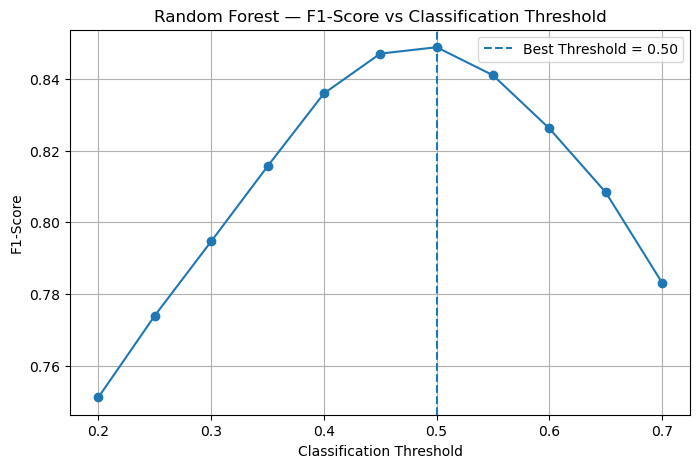

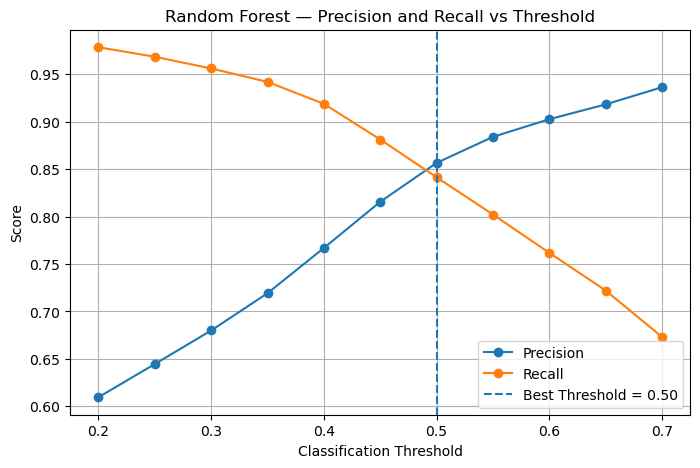


Threshold analysis saved successfully.


In [46]:
# ============================================================
# CELL 46 — TUNED RANDOM FOREST THRESHOLD OPTIMIZATION
# ============================================================

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Get Prediction Probabilities
# ------------------------------------------------------------

# Probability of class 1 = booking cancellation
tuned_rf_y_proba = best_rf_model.predict_proba(
    X_test_processed
)[:, 1]

print("Prediction probabilities generated successfully.")


# ------------------------------------------------------------
# 2. Define Thresholds to Test
# ------------------------------------------------------------

thresholds = np.arange(
    0.20,
    0.71,
    0.05
)


# ------------------------------------------------------------
# 3. Evaluate Model at Different Thresholds
# ------------------------------------------------------------

threshold_results = []

for threshold in thresholds:

    # Convert probabilities into class predictions
    threshold_pred = (
        tuned_rf_y_proba >= threshold
    ).astype(int)

    # Calculate metrics
    accuracy = accuracy_score(
        y_test,
        threshold_pred
    )

    precision = precision_score(
        y_test,
        threshold_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        threshold_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        threshold_pred,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": round(threshold, 2),
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })


# ------------------------------------------------------------
# 4. Create Threshold Results DataFrame
# ------------------------------------------------------------

threshold_results_df = pd.DataFrame(
    threshold_results
)

print("\n" + "=" * 70)
print("TUNED RANDOM FOREST — THRESHOLD ANALYSIS")
print("=" * 70)

display(
    threshold_results_df.round(4)
)


# ------------------------------------------------------------
# 5. Find Best Threshold Based on F1-Score
# ------------------------------------------------------------

best_threshold_row = threshold_results_df.loc[
    threshold_results_df["F1-Score"].idxmax()
]

best_threshold = float(
    best_threshold_row["Threshold"]
)

print("\n" + "=" * 70)
print("BEST THRESHOLD")
print("=" * 70)

print(f"Best Threshold : {best_threshold:.2f}")
print(
    f"Best F1-Score  : "
    f"{best_threshold_row['F1-Score']:.4f}"
)
print(
    f"Precision      : "
    f"{best_threshold_row['Precision']:.4f}"
)
print(
    f"Recall         : "
    f"{best_threshold_row['Recall']:.4f}"
)
print(
    f"Accuracy       : "
    f"{best_threshold_row['Accuracy']:.4f}"
)


# ------------------------------------------------------------
# 6. Generate Final Predictions Using Best Threshold
# ------------------------------------------------------------

tuned_rf_best_threshold_pred = (
    tuned_rf_y_proba >= best_threshold
).astype(int)


# ------------------------------------------------------------
# 7. Calculate Final Threshold-Optimized Metrics
# ------------------------------------------------------------

threshold_rf_accuracy = accuracy_score(
    y_test,
    tuned_rf_best_threshold_pred
)

threshold_rf_precision = precision_score(
    y_test,
    tuned_rf_best_threshold_pred,
    zero_division=0
)

threshold_rf_recall = recall_score(
    y_test,
    tuned_rf_best_threshold_pred,
    zero_division=0
)

threshold_rf_f1 = f1_score(
    y_test,
    tuned_rf_best_threshold_pred,
    zero_division=0
)

threshold_rf_roc_auc = roc_auc_score(
    y_test,
    tuned_rf_y_proba
)


# ------------------------------------------------------------
# 8. Display Final Threshold-Optimized Performance
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TUNED RANDOM FOREST — OPTIMIZED THRESHOLD PERFORMANCE")
print("=" * 70)

print(f"Threshold : {best_threshold:.2f}")
print(f"Accuracy  : {threshold_rf_accuracy:.4f}")
print(f"Precision : {threshold_rf_precision:.4f}")
print(f"Recall    : {threshold_rf_recall:.4f}")
print(f"F1-Score  : {threshold_rf_f1:.4f}")
print(f"ROC-AUC   : {threshold_rf_roc_auc:.4f}")


# ------------------------------------------------------------
# 9. Classification Report
# ------------------------------------------------------------

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        tuned_rf_best_threshold_pred,
        zero_division=0
    )
)


# ------------------------------------------------------------
# 10. Confusion Matrix
# ------------------------------------------------------------

threshold_rf_cm = confusion_matrix(
    y_test,
    tuned_rf_best_threshold_pred
)

print("\nConfusion Matrix:")
print(threshold_rf_cm)


# ------------------------------------------------------------
# 11. Store Threshold-Optimized Results
# ------------------------------------------------------------

threshold_rf_results = {
    "Model": "Random Forest Tuned + Optimized Threshold",
    "Threshold": best_threshold,
    "Accuracy": threshold_rf_accuracy,
    "Precision": threshold_rf_precision,
    "Recall": threshold_rf_recall,
    "F1-Score": threshold_rf_f1,
    "ROC-AUC": threshold_rf_roc_auc
}


# ------------------------------------------------------------
# 12. Plot F1-Score vs Threshold
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["F1-Score"],
    marker="o"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best Threshold = {best_threshold:.2f}"
)

plt.xlabel("Classification Threshold")
plt.ylabel("F1-Score")
plt.title("Random Forest — F1-Score vs Classification Threshold")
plt.legend()
plt.grid(True)

plt.show()


# ------------------------------------------------------------
# 13. Plot Precision and Recall vs Threshold
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Recall"],
    marker="o",
    label="Recall"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best Threshold = {best_threshold:.2f}"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Random Forest — Precision and Recall vs Threshold")
plt.legend()
plt.grid(True)

plt.show()


# ------------------------------------------------------------
# 14. Save Threshold Analysis Results
# ------------------------------------------------------------

threshold_results_df.to_csv(
    "../data/rf_threshold_analysis.csv",
    index=False
)

print("\nThreshold analysis saved successfully.")

In [47]:
# ============================================================
# CELL 47 — FINAL MODEL COMPARISON
# ============================================================

import pandas as pd


# ------------------------------------------------------------
# 1. Create Clean Baseline Results
# ------------------------------------------------------------

# Logistic Regression — DEFAULT THRESHOLD = 0.50
logistic_baseline_pred = (
    y_pred_proba >= 0.50
).astype(int)

logistic_baseline_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(
        y_test,
        logistic_baseline_pred
    ),
    "Precision": precision_score(
        y_test,
        logistic_baseline_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        logistic_baseline_pred,
        zero_division=0
    ),
    "F1-Score": f1_score(
        y_test,
        logistic_baseline_pred,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        y_pred_proba
    )
}


# ------------------------------------------------------------
# 2. Random Forest Baseline
# ------------------------------------------------------------

rf_baseline_results = {
    "Model": "Random Forest",
    "Accuracy": rf_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1-Score": rf_f1,
    "ROC-AUC": rf_roc_auc
}


# ------------------------------------------------------------
# 3. XGBoost Baseline
# ------------------------------------------------------------

xgb_baseline_results = {
    "Model": "XGBoost",
    "Accuracy": xgb_accuracy,
    "Precision": xgb_precision,
    "Recall": xgb_recall,
    "F1-Score": xgb_f1,
    "ROC-AUC": xgb_roc_auc
}


# ------------------------------------------------------------
# 4. Tuned Random Forest
# ------------------------------------------------------------

tuned_rf_baseline_results = {
    "Model": "Random Forest Tuned",
    "Accuracy": tuned_rf_accuracy,
    "Precision": tuned_rf_precision,
    "Recall": tuned_rf_recall,
    "F1-Score": tuned_rf_f1,
    "ROC-AUC": tuned_rf_roc_auc
}


# ------------------------------------------------------------
# 5. Tuned RF + Optimized Threshold
# ------------------------------------------------------------

final_rf_results = {
    "Model": "Random Forest Tuned + Optimized Threshold",
    "Accuracy": threshold_rf_accuracy,
    "Precision": threshold_rf_precision,
    "Recall": threshold_rf_recall,
    "F1-Score": threshold_rf_f1,
    "ROC-AUC": threshold_rf_roc_auc
}


# ------------------------------------------------------------
# 6. Create Final Comparison Table
# ------------------------------------------------------------

final_model_comparison = pd.DataFrame([
    logistic_baseline_results,
    rf_baseline_results,
    xgb_baseline_results,
    tuned_rf_baseline_results,
    final_rf_results
])


# ------------------------------------------------------------
# 7. Sort by F1-Score
# ------------------------------------------------------------

final_model_comparison = (
    final_model_comparison
    .sort_values(
        by="F1-Score",
        ascending=False
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 8. Display Final Comparison
# ------------------------------------------------------------

print("=" * 80)
print("FINAL MODEL COMPARISON")
print("=" * 80)

display(
    final_model_comparison.round(4)
)


# ------------------------------------------------------------
# 9. Identify Best Model by F1-Score
# ------------------------------------------------------------

best_model_row = final_model_comparison.iloc[0]

print("\n" + "=" * 80)
print("BEST MODEL BASED ON F1-SCORE")
print("=" * 80)

print(
    f"Model     : {best_model_row['Model']}"
)

print(
    f"Accuracy  : {best_model_row['Accuracy']:.4f}"
)

print(
    f"Precision : {best_model_row['Precision']:.4f}"
)

print(
    f"Recall    : {best_model_row['Recall']:.4f}"
)

print(
    f"F1-Score  : {best_model_row['F1-Score']:.4f}"
)

print(
    f"ROC-AUC   : {best_model_row['ROC-AUC']:.4f}"
)


# ------------------------------------------------------------
# 10. Save Final Model Comparison
# ------------------------------------------------------------

final_model_comparison.to_csv(
    "../data/final_model_comparison.csv",
    index=False
)

print("\nFinal model comparison saved successfully.")

FINAL MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest Tuned,0.8891,0.8566,0.8413,0.8489,0.9548
1,Random Forest Tuned + Optimized Threshold,0.8891,0.8566,0.8413,0.8489,0.9548
2,Random Forest,0.8905,0.8880,0.8059,0.8450,0.9584
3,XGBoost,0.8746,0.8596,0.7907,0.8237,0.9483
4,Logistic Regression,0.8410,0.8228,0.7274,0.7721,0.9209



BEST MODEL BASED ON F1-SCORE
Model     : Random Forest Tuned
Accuracy  : 0.8891
Precision : 0.8566
Recall    : 0.8413
F1-Score  : 0.8489
ROC-AUC   : 0.9548

Final model comparison saved successfully.


In [48]:


import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Check SHAP Version
# ------------------------------------------------------------

print("SHAP version:", shap.__version__)


# ------------------------------------------------------------
# 2. Select a Sample from Test Data
# ------------------------------------------------------------


shap_sample_size = 2000

sample_size = min(
    shap_sample_size,
    X_test_processed.shape[0]
)

np.random.seed(42)

sample_indices = np.random.choice(
    X_test_processed.shape[0],
    size=sample_size,
    replace=False
)


# ------------------------------------------------------------
# 3. Convert SHAP Input to Numeric Dense Array
# ------------------------------------------------------------

X_test_shap = X_test_processed[
    sample_indices
]

# Convert sparse matrix to dense array if necessary
if hasattr(X_test_shap, "toarray"):
    X_test_shap = X_test_shap.toarray()

# Force numeric float32
X_test_shap = np.asarray(
    X_test_shap,
    dtype=np.float32
)


print("SHAP sample shape:", X_test_shap.shape)
print("SHAP sample dtype:", X_test_shap.dtype)


# ------------------------------------------------------------
# 4. Get Corresponding Target Values
# ------------------------------------------------------------

y_test_shap = y_test.iloc[
    sample_indices
].values


# ------------------------------------------------------------
# 5. Get Feature Names
# ------------------------------------------------------------

feature_names_shap = np.array(
    feature_names,
    dtype=str
)


print(
    "Number of feature names:",
    len(feature_names_shap)
)


# ------------------------------------------------------------
# 6. Create SHAP Tree Explainer
# ------------------------------------------------------------

print("\nCreating SHAP TreeExplainer...")

explainer = shap.TreeExplainer(
    best_rf_model
)

print("SHAP TreeExplainer created successfully.")


# ------------------------------------------------------------
# 7. Calculate SHAP Values
# ------------------------------------------------------------

print("\nCalculating SHAP values...")
print("This may take some time...")

shap_values_raw = explainer.shap_values(
    X_test_shap,
    check_additivity=False
)

print("SHAP values calculated successfully.")


# ------------------------------------------------------------
# 8. Handle Different SHAP Output Formats
# ------------------------------------------------------------

if isinstance(shap_values_raw, list):

    # Older SHAP versions
    shap_values_cancel = shap_values_raw[1]

elif isinstance(shap_values_raw, np.ndarray):

    if shap_values_raw.ndim == 3:

        # Newer SHAP versions
        shap_values_cancel = shap_values_raw[:, :, 1]

    else:

        shap_values_cancel = shap_values_raw

else:

    shap_values_cancel = np.asarray(
        shap_values_raw
    )


# ------------------------------------------------------------
# 9. Force SHAP Values to Numeric
# ------------------------------------------------------------

shap_values_cancel = np.asarray(
    shap_values_cancel,
    dtype=np.float32
)


# ------------------------------------------------------------
# 10. Create SHAP Explanation Object
# ------------------------------------------------------------

if isinstance(
    explainer.expected_value,
    np.ndarray
):

    base_value = explainer.expected_value[1]

else:

    base_value = explainer.expected_value


shap_explanation = shap.Explanation(
    values=shap_values_cancel,
    base_values=base_value,
    data=X_test_shap,
    feature_names=feature_names_shap
)


# ------------------------------------------------------------
# 11. Final Validation
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("SHAP SETUP COMPLETED")
print("=" * 60)

print(
    "Model              : Tuned Random Forest"
)

print(
    "Samples explained  :",
    sample_size
)

print(
    "Features explained :",
    len(feature_names_shap)
)

print(
    "Input dtype        :",
    X_test_shap.dtype
)

print(
    "SHAP matrix shape  :",
    shap_values_cancel.shape
)

print(
    "Feature names shape:",
    feature_names_shap.shape
)

SHAP version: 0.52.0
SHAP sample shape: (2000, 590)
SHAP sample dtype: float32
Number of feature names: 590

Creating SHAP TreeExplainer...
SHAP TreeExplainer created successfully.

Calculating SHAP values...
This may take some time...
SHAP values calculated successfully.

SHAP SETUP COMPLETED
Model              : Tuned Random Forest
Samples explained  : 2000
Features explained : 590
Input dtype        : float32
SHAP matrix shape  : (2000, 590)
Feature names shape: (590,)


In [51]:
# ============================================================
# CELL 50 — SAVE FINAL MODEL AND PREPROCESSOR
# ============================================================

import joblib
import os

# Create data directory if it does not exist
os.makedirs("../data", exist_ok=True)

# Save the preprocessing pipeline
joblib.dump(
    preprocessor,
    "../data/output/preprocessor.pkl"
)

# Save the final tuned Random Forest model
joblib.dump(
    best_rf_model,
    "../data/output/best_rf_model.pkl"
)

print("=" * 60)
print("MODEL ARTIFACTS SAVED SUCCESSFULLY")
print("=" * 60)

print("Preprocessor : ../data/preprocessor.pkl")
print("Model        : ../data/best_rf_model.pkl")

print("\nFinal Model:")
print(best_rf_model)

print("\nBest Threshold:")
print(best_threshold)

MODEL ARTIFACTS SAVED SUCCESSFULLY
Preprocessor : ../data/preprocessor.pkl
Model        : ../data/best_rf_model.pkl

Final Model:
RandomForestClassifier(bootstrap=False, class_weight='balanced', max_depth=25,
                       n_estimators=150, n_jobs=1, random_state=42)

Best Threshold:
0.5


In [53]:
import sklearn
import joblib

print("scikit-learn:", sklearn.__version__)
print("joblib:", joblib.__version__)

scikit-learn: 1.6.1
joblib: 1.4.2
